## Упражнение 03. Столбчатая диаграмма

In [1]:
import pandas as pd
import sqlite3
from pandas import DataFrame
from sqlite3 import Connection

### 1. Создаем соединение с базой данных с помощью библиотеки sqlite3

In [2]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

### 2. Делаем всё необходимое, чтобы получить график как на примере:
#### - Анализируй только пользователей (не учитывай админов);
#### - Размер шрифта и размер фигуры — те же, что раньше;
#### - Для каждого часа посчитай среднее число коммитов в рабочие дни и в выходные (если в конкретный час не было коммитов, не учитывай его при расчёте среднего). Используй эти значения для графика (пример агрегирования): Mon, 17–18: 5 commits, Tue, 17–18: 6 commits, Wed, 17–18: 7 commits;
#### - Палитру выбери на свой вкус — повторять цвета из примера не требуется.


In [3]:
query = """
SELECT checker.timestamp as datetime FROM checker 
WHERE checker.uid LIKE 'user_%';
"""
df: DataFrame = pd.io.sql.read_sql(query,conn,parse_dates=["datetime", ] )
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date
df["day_type"] = df["datetime"].dt.dayofweek.apply(lambda day: "weekend" if day >= 5 else "working_day", )
df

,datetime,hour,date,day_type
0,2020-04-17 05:19:02.744528,5,2020-04-17,working_day
1,2020-04-17 05:22:35.249331,5,2020-04-17,working_day
2,2020-04-17 05:22:45.549397,5,2020-04-17,working_day
3,2020-04-17 05:34:14.691200,5,2020-04-17,working_day
4,2020-04-17 05:34:24.422370,5,2020-04-17,working_day
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,20,2020-05-21,working_day
3203,2020-05-21 20:22:41.785725,20,2020-05-21,working_day
3204,2020-05-21 20:22:41.877806,20,2020-05-21,working_day
3205,2020-05-21 20:37:00.129678,20,2020-05-21,working_day


In [4]:
df = df.groupby(['date','hour','day_type']).size().reset_index(name='commits', )
df

,date,hour,day_type,commits
0,2020-04-17,5,working_day,13
1,2020-04-17,11,working_day,8
2,2020-04-17,12,working_day,2
3,2020-04-18,7,weekend,1
4,2020-04-18,13,weekend,5
...,...,...,...,...
283,2020-05-21,16,working_day,4
284,2020-05-21,17,working_day,1
285,2020-05-21,18,working_day,2
286,2020-05-21,19,working_day,8


In [5]:
df = df.groupby(["hour", "day_type", ], )["commits"].mean().reset_index(name="avg_commits", )
df

,hour,day_type,avg_commits
0,0,weekend,2.000000
1,0,working_day,3.000000
2,1,weekend,6.000000
3,3,weekend,1.000000
4,3,working_day,2.000000
5,5,weekend,2.000000
6,5,working_day,7.500000
7,6,working_day,1.500000
8,7,weekend,4.000000
9,7,working_day,5.166667


In [6]:
df = df.pivot_table(index="hour", columns="day_type", values="avg_commits", fill_value=0, ).reset_index()
df

day_type,hour,weekend,working_day
0,0,2.000000,3.000000
1,1,6.000000,0.000000
2,3,1.000000,2.000000
3,5,2.000000,7.500000
4,6,0.000000,1.500000
5,7,4.000000,5.166667
6,8,7.000000,3.700000
7,9,3.666667,6.000000
8,10,7.000000,13.200000
9,11,23.600000,6.769231


In [7]:
df = pd.merge(DataFrame({"hour": range(24, ), }, ),df, on="hour", how="left",)
df.fillna(0, inplace=True, )
df

,hour,weekend,working_day
0,0,2.000000,3.000000
1,1,6.000000,0.000000
2,2,0.000000,0.000000
3,3,1.000000,2.000000
4,4,0.000000,0.000000
5,5,2.000000,7.500000
6,6,0.000000,1.500000
7,7,4.000000,5.166667
8,8,7.000000,3.700000
9,9,3.666667,6.000000


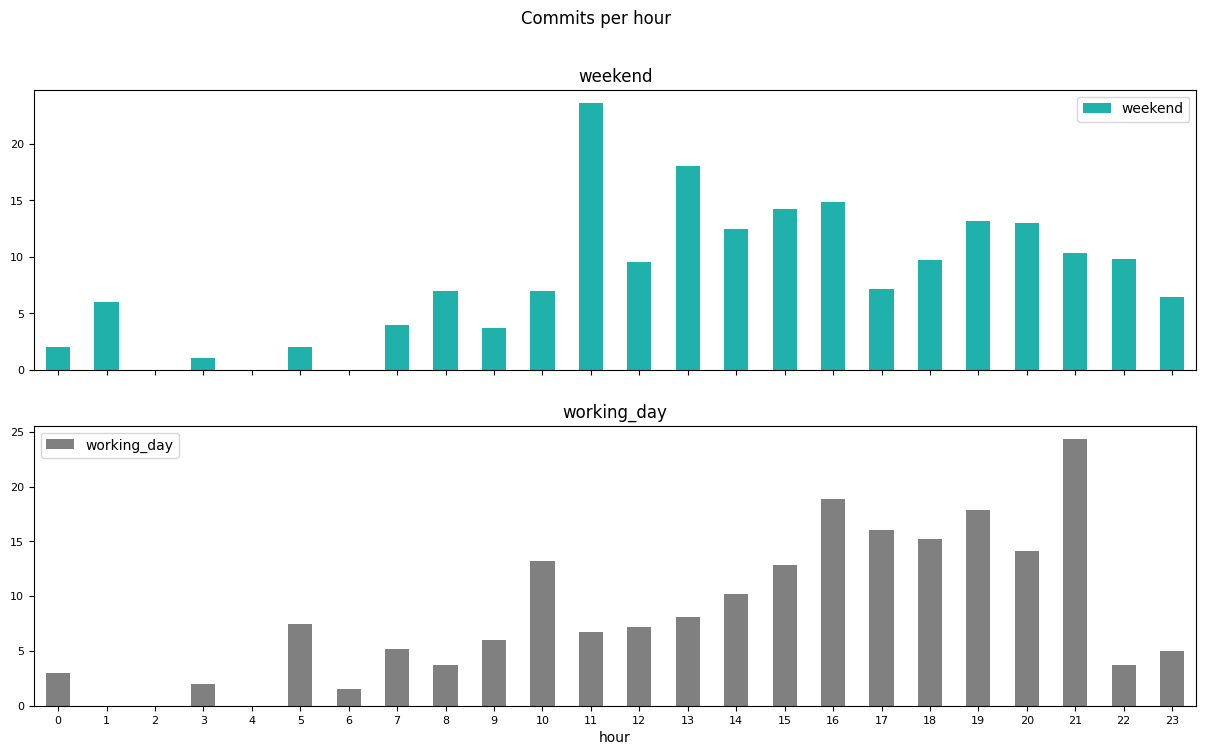

In [8]:
palette = ["lightseagreen", "grey", ]
df.plot.bar(
    x="hour",
    y=["weekend", "working_day", ],
    rot=0,
    fontsize=8,
    color=palette,
    subplots=True,
    figsize=(15, 8, ),
    title="Commits per hour",
);

### Различается ли динамика в рабочие дни и в выходные?

In [9]:
print(f"{df.sort_values(by=["working_day", ], ).index[-1]} and {df.sort_values(by=["weekend", ], ).index[-1]}.", )

21 and 11.


### Закрываем соединение с базой данных.

In [10]:
conn.close()